<a href="https://colab.research.google.com/github/Desmond-Tiny/Deep-Learning/blob/main/language_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# SimpleRNN, LSTM, GRU

In [ ]:
import yfinance as yf

ms=yf.download('MSFT',start='2012-01-01',end='2023-12-31',progress=False)


In [ ]:
ms.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,26.549999,26.959999,26.389999,26.770000,21.200510,64731500
2012-01-04,26.820000,27.469999,26.780001,27.400000,21.699446,80516100
2012-01-05,27.379999,27.730000,27.290001,27.680000,21.921186,56081400
2012-01-06,27.530001,28.190001,27.530001,28.110001,22.261723,99455500
2012-01-09,28.049999,28.100000,27.719999,27.740000,21.968700,59706800


In [ ]:
ms[:"2021"].Close.values.reshape(-1,1).shape

(2517, 1)

In [ ]:
train=ms[:"2021"].Close.values.reshape(-1,1)
test=ms["2022":].Close.values.reshape(-1,1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
train=scaler.fit_transform(train)
test=scaler.transform(test)

In [ ]:
x_step=10
y_step=1

In [ ]:
def convert_data_extra(data,x_step,y_step):
  X,Y = [],[]
  for i in range(len(data)-x_step-y_step+1):
    d=i+x_step

    X.append(data[i:d])
    Y.append(data[d:d+y_step])

  return np.array(X),np.array(Y)

x_step=10
y_step=1
trainX,trainY=convert_data_extra(train,x_step,y_step)
testX,testY=convert_data_extra(test,x_step,y_step)


trainX.shape,testX.shape


((2507, 10, 1), (491, 10, 1))

In [ ]:
trainX=np.reshape(trainX,(trainX.shape[0],trainX.shape[1],1))
testX=np.reshape(testX,(testX.shape[0],testX.shape[1],1))

trainX.shape,testX.shape

((2507, 10, 1), (491, 10, 1))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN,LSTM


In [ ]:
trainX.shape,testX.shape

((2507, 10, 1), (491, 10, 1))

In [ ]:
# from tensorflow.keras.layers import LSTM
# model = Sequential()
# model.add(LSTM(units=64,activation='tanh',input_shape=(None,1),return_sequences=False))
# # model.add(LSTM(units=64,activation='tanh',input_shape=(None,1),return_sequences=True))
# # model.add(LSTM(units=64,activation='tanh'))
# model.add(Dense(1))
# model.compile(loss='mean_squared_error',optimizer='adam')

# history = model.fit(trainX,trainY,epochs=100,batch_size=16)


# score=model.evaluate(trainX,trainY)
# print('train score',score)
# score=model.evaluate(testX,testY)
# print('test score',score)



In [ ]:
# from tensorflow.keras.layers import LSTM
# model = Sequential()
# model.add(LSTM(units=64,activation='tanh',input_shape=(None,1),return_sequences=True))
# model.add(LSTM(units=64,activation='tanh',input_shape=(None,1),return_sequences=True))
# model.add(LSTM(units=64,activation='tanh'))
# model.add(Dense(1))
# model.compile(loss='mean_squared_error',optimizer='adam')

# history = model.fit(trainX,trainY,epochs=100,batch_size=16)


# score=model.evaluate(trainX,trainY)
# print('train score',score)
# score=model.evaluate(testX,testY)
# print('test score',score)



In [ ]:
# model.summary()

In [ ]:
# from tensorflow.keras.utils import plot_model

# plot_model(model)

In [ ]:
# train_preds=model.predict(trainX)
# test_preds=model.predict(testX)

In [ ]:
# predicted=np.concatenate((train_preds,test_preds),axis=0)

In [ ]:
# plt.plot(ms.Close.values,label='real')
# plt.plot(scaler.inverse_transform(predicted),label='predicted')
# plt.axvline(x=len(train),c='r')
# plt.legend()
# plt.show()

In [ ]:
# preds=model.predict(testX)
# preds.shape

In [ ]:
# simple LSTM
# multiple LSTM (DEEP)

In [ ]:
# trainX.shape,testX.shape

In [ ]:
# train_preds=model.predict(trainX)
# test_preds=model.predict(testX)

In [ ]:
# predicted=np.concatenate((train_preds,test_preds),axis=0)

In [ ]:
# plt.plot(ms.Close.values,label='real')
# plt.plot(scaler.inverse_transform(predicted),label='predicted')
# plt.axvline(x=len(train),c='r')
# plt.legend()
# plt.show()

In [ ]:
# preds=model.predict(testX)
# preds.shape

# Functional API

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
housing=fetch_california_housing()
X_train_full,X_test,y_train_full,y_test=train_test_split(housing.data,housing.target,random_state=1403)
X_train,X_valid,y_train,y_valid=train_test_split(X_train_full,y_train_full,random_state=1403)


In [ ]:
from tensorflow.keras.layers import Dense,Concatenate,Normalization,Input
from tensorflow.keras import Model

In [ ]:
X_train.shape

(11610, 8)

In [ ]:
normalization_layer=Normalization() # *
hidden_layer1=Dense(30,activation='relu')
hidden_layer2=Dense(30,activation='relu')
concat_layer=Concatenate()
output_layer=Dense(1)

input_=Input(shape=X_train.shape[1:])
normalized=normalization_layer(input_)
hidden1=hidden_layer1(normalized)
hidden2=hidden_layer2(hidden1)
concat=concat_layer([normalized,hidden2])
output=output_layer(concat)

model = Model(inputs=[input_],outputs=[output])



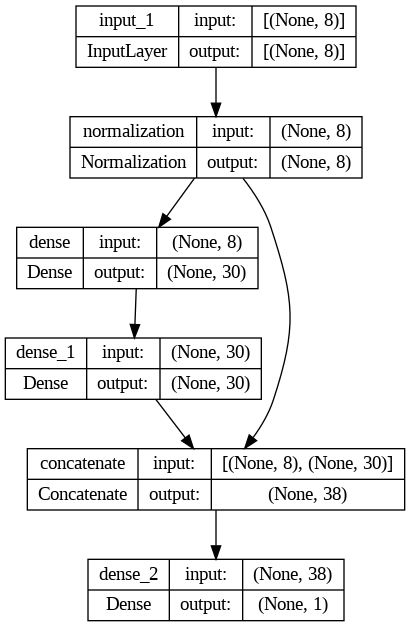

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model,show_shapes=True)

In [ ]:
# model.compile(loss='mse',optimizer='adam',metrics=['RootMeanSquaredError'])
# normalization_layer.adapt(X_train)
# history = model.fit(X_train,y_train,epochs=20,validation_data=(X_valid,y_valid))
# model.evaluate(X_test,y_test)

In [ ]:
# # Rewrite this based on functional api

# from tensorflow.keras.layers import LSTM
# model = Sequential()
# model.add(LSTM(units=64,activation='tanh',input_shape=(None,1),return_sequences=True))
# model.add(LSTM(units=64,activation='tanh',input_shape=(None,1),return_sequences=True))
# model.add(LSTM(units=64,activation='tanh'))
# model.add(Dense(1))
# model.compile(loss='mean_squared_error',optimizer='adam')

# history = model.fit(trainX,trainY,epochs=100,batch_size=16)


# score=model.evaluate(trainX,trainY)
# print('train score',score)
# score=model.evaluate(testX,testY)
# print('test score',score)



Epoch 1/100
157/157 [==============================] - 9s 16ms/step - loss: 0.0052
Epoch 2/100
157/157 [==============================] - 4s 26ms/step - loss: 1.9685e-04
Epoch 3/100
157/157 [==============================] - 4s 26ms/step - loss: 2.0327e-04
Epoch 4/100
157/157 [==============================] - 4s 27ms/step - loss: 2.3008e-04
Epoch 5/100
157/157 [==============================] - 4s 28ms/step - loss: 2.3314e-04
Epoch 6/100
157/157 [==============================] - 4s 25ms/step - loss: 2.1079e-04
Epoch 7/100
157/157 [==============================] - 4s 28ms/step - loss: 2.1182e-04
Epoch 8/100
157/157 [==============================] - 4s 22ms/step - loss: 1.9878e-04
Epoch 9/100
157/157 [==============================] - 3s 21ms/step - loss: 2.3440e-04
Epoch 10/100
157/157 [==============================] - 3s 21ms/step - loss: 2.6446e-04
Epoch 11/100
157/157 [==============================] - 4s 27ms/step - loss: 2.0210e-04
Epoch 12/100
157/157 [=======================

KeyboardInterrupt: 

In [ ]:
trainX.shape

(2507, 10, 1)

In [ ]:
from tensorflow.keras.layers import LSTM


lstm1=LSTM(units=60,activation='tanh',return_sequences=True)
lstm2=LSTM(units=60,activation='tanh',return_sequences=True)
lstm3=LSTM(units=60,activation='tanh')
output=Dense(1)


input_=Input(shape=trainX.shape[1:])
x=lstm1(input_)
x=lstm2(x)
x=lstm3(x)
x=output(x)

model=Model(inputs=[input_],outputs=[x])

model.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 10, 1)]           0         
                                                                 
 lstm_3 (LSTM)               (None, 10, 60)            14880     
                                                                 
 lstm_4 (LSTM)               (None, 10, 60)            29040     
                                                                 
 lstm_5 (LSTM)               (None, 60)                29040     
                                                                 
 dense_4 (Dense)             (None, 1)                 61        
                                                                 
Total params: 73021 (285.24 KB)
Trainable params: 73021 (285.24 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
from tensorflow.keras.layers import LSTM


input_=Input(shape=trainX.shape[1:])

lstm1=LSTM(units=60,activation='tanh',return_sequences=True)(input_)
lstm2=LSTM(units=60,activation='tanh',return_sequences=True)(lstm1)
lstm3=LSTM(units=60,activation='tanh')(lstm2)
output=Dense(1)(lstm3)


model=Model(inputs=[input_],outputs=[output])

model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 10, 1)]           0         
                                                                 
 lstm_6 (LSTM)               (None, 10, 60)            14880     
                                                                 
 lstm_7 (LSTM)               (None, 10, 60)            29040     
                                                                 
 lstm_8 (LSTM)               (None, 60)                29040     
                                                                 
 dense_5 (Dense)             (None, 1)                 61        
                                                                 
Total params: 73021 (285.24 KB)
Trainable params: 73021 (285.24 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:

# model.compile(loss='mean_squared_error',optimizer='adam')

# history = model.fit(trainX,trainY,epochs=100,batch_size=16)


# score=model.evaluate(trainX,trainY)
# print('train score',score)
# score=model.evaluate(testX,testY)
# print('test score',score)


# Emebdding

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2024-07-18 05:43:04--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2024-07-18 05:43:04--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2024-07-18 05:43:04--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [ ]:
import numpy as np

import os

In [ ]:
dir='.'
embeddings_index={}
with open(f'{dir}/glove.6B.100d.txt',encoding='utf-8') as f:
  lines=f.readlines()
  for line in lines:
    values=line.split()
    word=values[0]
    embed=values[1:]
    weights=np.asarray(embed,dtype='float32')
    embeddings_index[word]=weights

len(embeddings_index.keys())

400000

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(u,v):
  return np.squeeze(cosine_similarity(u.reshape(1,-1),v.reshape(1,-1)))


In [ ]:
embeddings_index['father']

array([ 0.64706 , -0.068067,  0.15468 , -0.17408 , -0.29134 ,  0.76999 ,
       -0.3192  , -0.25663 , -0.25082 , -0.036737, -0.25509 ,  0.29636 ,
        0.5776  ,  0.49641 ,  0.19167 , -0.83888 ,  0.58482 , -0.38717 ,
       -0.71591 ,  0.9519  , -0.37966 , -0.1131  ,  0.47154 ,  0.20921 ,
        0.38197 ,  0.067582, -0.92879 , -1.1237  ,  0.84831 ,  0.68744 ,
       -0.15472 ,  0.92714 ,  0.53371 , -0.037392, -0.856   ,  0.19056 ,
       -0.014594,  0.15186 ,  0.53514 , -0.20306 , -0.35164 ,  0.33152 ,
        1.1306  , -0.72787 , -0.19724 ,  0.031659, -0.24041 , -0.057617,
        0.60473 , -0.49233 , -0.24405 , -0.3184  ,  0.96156 ,  1.0895  ,
        0.21534 , -2.0542  , -1.0615  ,  0.052439,  0.57958 ,  0.2748  ,
        0.91587 ,  0.85195 ,  0.36113 , -0.31901 ,  0.7784  , -0.36865 ,
        0.64387 ,  0.33104 , -0.27181 ,  0.58524 , -0.15143 ,  0.11121 ,
        0.2126  , -0.60345 ,  0.16148 ,  0.32952 , -0.1354  , -0.30629 ,
       -0.89143 ,  0.091912,  0.49753 ,  0.55932 , 

In [ ]:
# father,mother
# tehran, paris
# france, iran

# france - paris , tehran - iran
# france - paris, iran - tehran

In [ ]:
father = embeddings_index['father']
mother = embeddings_index['mother']
tehran = embeddings_index['tehran']
paris = embeddings_index['paris']
france = embeddings_index['france']
iran = embeddings_index['iran']

In [ ]:
similarity(father,mother)

array(0.8656661, dtype=float32)

In [ ]:
similarity(tehran,paris)

array(0.45368147, dtype=float32)

In [ ]:
similarity(france,iran)

array(0.46655208, dtype=float32)

In [ ]:
similarity(france - paris,iran - tehran)

array(0.6854124, dtype=float32)

In [ ]:
similarity(france - paris,tehran - iran)

array(-0.6854124, dtype=float32)

In [ ]:
def complete_analogy(word_a,word_b,word_c,embeddings_index):
  word_a,word_b,word_c = word_a.lower(),word_b.lower(),word_c.lower()

  e_a,e_b,e_c = embeddings_index[word_a],embeddings_index[word_b],embeddings_index[word_c]

  words = embeddings_index.keys()
  max_cosine_sim=float('-inf')
  best_word=None

  for w in words:
    if w in [word_a,word_b,word_c]:
      continue

    cosine_sim = similarity(e_b - e_a, embeddings_index[w] - e_c)

    if cosine_sim > max_cosine_sim:
      max_cosine_sim = cosine_sim
      best_word = w


  return best_word


In [ ]:
# complete_analogy('china','chinese','iran',embeddings_index)


In [ ]:
# india,delhi,iran
# complete_analogy('india','delhi','iran',embeddings_index)


In [ ]:
# man,woman,boy
# complete_analogy('man','woman','boy',embeddings_index)


In [ ]:
# small,smaller,big
# complete_analogy('small','smaller','big',embeddings_index)


In [ ]:
# iran,farsi,germany
# complete_analogy('iran','persian','germany',embeddings_index)


In [ ]:
# embeddings_index['friends']

In [ ]:
def complete_analogy2(word_a,word_b,word_c,embeddings_index,limit=5):
  word_a,word_b,word_c = word_a.lower(),word_b.lower(),word_c.lower()

  e_a,e_b,e_c = embeddings_index[word_a],embeddings_index[word_b],embeddings_index[word_c]

  words = embeddings_index.keys()
  max_cosine_sim=float('-inf')
  best_word={}

  for w in words:
    #if len(best_word.keys()) >=limit:
      #break
    if w in [word_a,word_b,word_c]:
      continue

    cosine_sim = similarity(e_b - e_a, embeddings_index[w] - e_c)

    if cosine_sim > max_cosine_sim:
      max_cosine_sim = cosine_sim
      best_word[w] = cosine_sim


  return sorted(best_word.items(),key=lambda x:x[1],reverse=True)[:limit]

In [ ]:
complete_analogy2('china','chinese','iran',embeddings_index)


[('iranian', array(0.796303, dtype=float32)),
 ('turkish', array(0.6328089, dtype=float32)),
 ('greek', array(0.60495967, dtype=float32)),
 ('iraqi', array(0.57764673, dtype=float32)),
 ('russian', array(0.5115686, dtype=float32))]

In [ ]:
embeddings_index['iranian']

array([ 0.74124  ,  0.11045  ,  0.56782  , -0.065495 ,  0.33851  ,
       -0.39176  , -0.80394  , -0.60198  ,  0.24519  ,  1.7734   ,
        0.13633  , -0.27694  ,  1.3715   ,  0.15865  , -0.62266  ,
        0.56927  , -0.40329  , -0.76107  , -0.78117  , -0.12852  ,
        0.019008 , -0.014354 ,  0.30912  , -0.10408  , -0.80433  ,
       -0.069777 , -0.44361  ,  0.24099  ,  1.1195   ,  0.96748  ,
       -0.24555  , -0.10438  , -0.6079   , -0.328    ,  0.045156 ,
       -0.14803  ,  0.12835  ,  0.29054  , -0.23727  ,  0.25611  ,
       -1.1144   ,  0.10325  ,  0.15149  ,  0.26347  ,  0.86872  ,
       -1.3337   ,  0.14206  , -0.17506  , -0.16883  ,  0.47317  ,
        0.44096  ,  0.46944  ,  0.99419  ,  1.0463   , -0.65101  ,
       -0.80263  , -0.47383  ,  0.064334 ,  1.4847   ,  0.056562 ,
       -0.1044   , -0.059878 , -0.11622  , -0.74952  ,  0.36067  ,
        0.53188  ,  0.29301  ,  0.15941  , -0.84449  ,  0.37091  ,
        0.76953  , -0.12229  ,  0.54898  , -0.33458  ,  0.0019

In [ ]:
embeddings_index['can']

array([-0.71766 ,  0.80871 ,  0.31868 , -0.53589 , -0.31998 ,  0.18929 ,
       -0.23241 ,  0.44233 ,  0.25649 , -0.32093 , -0.16951 ,  0.14993 ,
        0.55681 ,  0.33992 ,  0.028335, -0.38295 ,  0.43366 ,  0.73026 ,
       -0.79863 ,  0.2954  ,  0.017078, -0.39545 ,  0.19967 ,  0.081727,
        0.18943 ,  0.095973, -0.033138, -0.69888 ,  0.41562 , -0.67422 ,
       -0.059873,  1.23    , -0.31391 ,  0.15313 ,  0.82508 ,  0.49345 ,
       -0.051686,  0.31035 ,  0.25147 , -0.36228 , -0.14969 , -0.39609 ,
       -0.73853 , -1.0716  , -0.21775 ,  0.23018 ,  0.078188, -0.48584 ,
       -0.082414, -1.0405  ,  0.44389 , -0.2964  ,  0.036505,  1.2115  ,
        0.50287 , -2.2662  , -0.073575,  0.010925,  1.7266  ,  0.63332 ,
       -0.23215 ,  1.2603  , -0.43585 , -0.082693,  1.1903  ,  0.34009 ,
        0.59365 ,  0.20098 ,  0.1016  , -1.1757  , -0.1187  , -0.59569 ,
        0.34427 , -0.48687 ,  0.34953 , -0.44521 , -0.13131 , -0.19316 ,
       -0.55304 ,  0.075953,  0.6893  , -0.26706 , 

In [ ]:
# OOV

In [ ]:
# Tokenizer

In [ ]:
#embeddings_index["'s"]

In [ ]:
embeddings_index['sara'],embeddings_index["'s"],embeddings_index['car']

(array([-0.23295 , -0.56497 , -0.19626 ,  0.19975 , -0.032222, -0.38232 ,
        -0.029728,  0.73616 ,  0.58323 , -0.71157 ,  0.39422 , -0.30442 ,
        -0.24572 ,  0.17488 , -0.18663 , -0.11994 ,  0.84987 ,  0.10857 ,
        -0.68445 ,  1.0525  ,  0.13365 ,  0.064299,  0.83515 ,  1.1555  ,
         0.1825  ,  0.69425 ,  0.6002  , -0.94532 , -0.31604 ,  0.58163 ,
        -0.29775 ,  0.16136 ,  0.40526 , -0.34496 , -0.29017 , -0.11178 ,
         0.63977 ,  0.48543 ,  0.37657 , -0.31775 ,  0.13887 , -0.27289 ,
         0.17381 ,  0.1177  , -0.27849 , -0.20353 , -0.30238 ,  0.16277 ,
         0.30644 ,  0.37662 , -0.16699 ,  0.32401 ,  0.24019 ,  0.49195 ,
         0.17648 , -0.77485 , -0.71654 ,  0.29765 , -0.4008  , -0.43771 ,
         0.6624  ,  0.26549 ,  0.31074 , -0.13082 , -0.22054 , -0.37281 ,
         0.74097 ,  0.81706 ,  0.033166,  0.062954, -0.18385 ,  0.48533 ,
        -0.64557 ,  0.036766,  0.61796 ,  0.50265 , -0.38559 , -0.15885 ,
         0.057809, -0.025447, -0.24995

In [ ]:
# word embedding
# sentence embedding -> concat,avg,sum,
# sara's car is beautiful. ->

# Exercise 3

In [ ]:
words=['father','china','chinese','iran','india','man','woman','son']

In [ ]:
vectors=np.array([embeddings_index[w] for w in words])

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca=PCA(n_components=2)

In [ ]:
pca.fit(vectors)
x_emb=pca.transform(vectors)
vectors.shape,x_emb.shape

((8, 100), (8, 2))

In [ ]:
x_emb[0],x_emb[-1]

(array([-3.3260221 , -0.47949806], dtype=float32),
 array([-3.4997816, -0.6605845], dtype=float32))

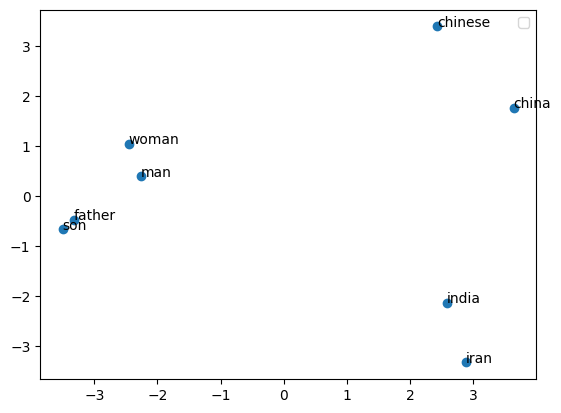

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_emb[:,0],x_emb[:,1])
for label, x, y in zip(words, x_emb[:, 0], x_emb[:, 1]):
  plt.annotate(label, xy=(x, y), xytext=(0, 0), textcoords="offset points")

plt.legend()

In [ ]:
dir='.'
embeddings_index={}
words_to_index={}
index_to_words={}
with open(f'{dir}/glove.6B.100d.txt',encoding='utf-8') as f:
  lines=f.readlines()
  words =set()
  for line in lines:
    values=line.split()
    word=values[0]
    embed=values[1:]
    weights=np.asarray(embed,dtype='float32')
    embeddings_index[word]=weights
    words.add(word)

  i = 1
  for w in sorted(words):
    words_to_index[w]=i
    index_to_words[i]=w
    i+=1


len(embeddings_index.keys())

400000

In [ ]:
word='sara'
words_to_index[word]

318272

In [ ]:
index_to_words[318272]

'sara'

In [ ]:
def senetences_to_indices(X,word_to_index,max_len):
  m=X.shape[0]
  X_indices=np.zeros((m,max_len))

  for i in range(m):
    sentence_words=X[i].lower().split()
    for j,w in enumerate(sentence_words):
      X_indices[i,j]=words_to_index[w]

  return X_indices

In [ ]:
X=np.array(['funny','lets go party','food is ready for you'])
X_indices=senetences_to_indices(X,words_to_index,max_len=5)
print(X)
print(X_indices)
# [[1234,0,0,0,0],[654,3242,123,0,0],[121,123,23,454,123]]

['funny' 'lets go party' 'food is ready for you']
[[155345.      0.      0.      0.      0.]
 [220930. 163237. 278093.      0.      0.]
 [151204. 192973. 302254. 151349. 394475.]]


In [ ]:
embeddings_index['ali'].shape[0]

100

In [ ]:
# Keras Functional API
from keras.layers import Embedding

def pretrained_embedding_layer(embeddings_index,words_to_index):
  vocab_len = len(words_to_index) + 1 # oov
  emb_dim=embeddings_index['ali'].shape[0]
  emb_matrix=np.zeros((vocab_len,emb_dim))
  for word,index in words_to_index.items():
    emb_matrix[index,:]=embeddings_index[word]


  embedding_layer = Embedding(vocab_len,emb_dim,trainable=False)
  embedding_layer.build((None,))
  embedding_layer.set_weights([emb_matrix])

  return embedding_layer

In [ ]:
e=pretrained_embedding_layer(embeddings_index,words_to_index)

In [ ]:
e

In [ ]:
b=Embedding(1000,100)
b

In [ ]:
x=Embedding()
x=pretrained_embedding_layer()
x=Dense()(x)
x=LSTM()(x)

TypeError: Dense.__init__() missing 1 required positional argument: 'units'

# Sentences -> Emoji


In [ ]:
!pip install emoji

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.4/431.4 kB 3.0 MB/s eta 0:00:00


In [ ]:
import emoji

emoji_dictionary = {"0": "\u2764\uFE0F",
                    "1": ":baseball:",
                    "2": ":smile:",
                    "3": ":disappointed:",
                    "4": ":fork_and_knife:"}

def label_to_emoji(label):

    return emoji.emojize(emoji_dictionary[str(label)],language='alias')

In [ ]:
!wget https://graphemy.ir/datasets/emojify.zip

--2024-07-18 07:31:53--  https://graphemy.ir/datasets/emojify.zip
Resolving graphemy.ir (graphemy.ir)... 91.107.181.26, 65.109.212.48
Connecting to graphemy.ir (graphemy.ir)|91.107.181.26|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8171 (8.0K) [application/zip]
Saving to: ‘emojify.zip’

emojify.zip         100%[===================>]   7.98K  --.-KB/s    in 0s      

2024-07-18 07:31:54 (82.5 MB/s) - ‘emojify.zip’ saved [8171/8171]



In [ ]:
!unzip emojify.zip

Archive:  emojify.zip
  inflating: emojify_data.csv        
  inflating: tes.csv                 
  inflating: tess.csv                
  inflating: tesss.csv               
  inflating: test_emoji.csv          
  inflating: testing.csv             
  inflating: train_emoji.csv         


In [ ]:
df=pd.read_csv('./train_emoji.csv',header=None)
df.head()

,0,1,2,3
0,never talk to me again,3,NaN,NaN
1,I am proud of your achievements,2,NaN,NaN
2,It is the worst day in my life,3,NaN,NaN
3,Miss you so much,0,NaN,[0]
4,food is life,4,NaN,NaN


In [ ]:
X_train,Y_train=df[0].values,df[1].values

In [ ]:
#X_train=X_train.reshape(132,1)

In [ ]:
test_df=pd.read_csv('./test_emoji.csv',header=None)
X_test,Y_test=test_df[0].values,test_df[1].values

In [ ]:
#X_test=X_test.reshape(56,1)

In [ ]:
X_test.shape,Y_test.shape

((56,), (56,))

In [ ]:
index=2

print(X_train[index],label_to_emoji(Y_train[index]))

It is the worst day in my life 😞


In [ ]:
from tensorflow.keras.utils import to_categorical

Y_train_oh=to_categorical(Y_train,5)
Y_test_oh=to_categorical(Y_test,5)

In [ ]:
Y_test_oh[1]

array([0., 0., 0., 1., 0.], dtype=float32)

Build a Deep LSTM Model:

- Input
- pretrained_embedding_layer
- AveragePooling1D
- Flatten
- MLP (Dense, 2Denses) -> af? number of neurons?



Use Functional API only.

In [ ]:
X_train[0]

'never talk to me again'

In [ ]:
max(X_train,key=len),len(max(X_train,key=len))

('I am so impressed by your dedication to this project', 52)

In [ ]:
max_len=len(max(X_train,key=len).split())
max_len

10

In [ ]:
X_train_sequences=senetences_to_indices(X_train,words_to_index,max_len=max_len)
X_train[1],X_train_sequences[1]

('I am proud of your achievements',
 array([185457.,  52943., 293982., 268046., 394565.,  45460.,      0.,
             0.,      0.,      0.]))

In [ ]:
from tensorflow.keras.layers import Input,AveragePooling1D,Dense,Flatten
from tensorflow.keras.models import Model

In [ ]:
def EmojifyModel(input_shape,embeddings_index,words_to_index):
  sentence_indices=Input(input_shape,dtype=np.int32)
  embedding_layer=pretrained_embedding_layer(embeddings_index,words_to_index)
  embeddings=embedding_layer(sentence_indices)
  x=AveragePooling1D(pool_size=10)(embeddings)
  x=Flatten()(x)

  x=Dense(5,activation='softmax')(x)
  model=Model(sentence_indices,x)
  return model

In [ ]:
model = EmojifyModel((max_len,),embeddings_index,words_to_index)
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 10)]              0         
                                                                 
 embedding_4 (Embedding)     (None, 10, 100)           40000100  
                                                                 
 average_pooling1d_2 (Avera  (None, 1, 100)            0         
 gePooling1D)                                                    
                                                                 
 flatten_2 (Flatten)         (None, 100)               0         
                                                                 
 dense_6 (Dense)             (None, 5)                 505       
                                                                 
Total params: 40000605 (152.59 MB)
Trainable params: 505 (1.97 KB)
Non-trainable params: 40000100 (152.59 MB)
_______________

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

In [ ]:
model.fit(X_train_sequences,Y_train_oh,epochs=50,batch_size=32,shuffle=True)

Epoch 1/50
5/5 [==============================] - 1s 6ms/step - loss: 1.6294 - accuracy: 0.1439
Epoch 2/50
5/5 [==============================] - 0s 4ms/step - loss: 1.6212 - accuracy: 0.2045
Epoch 3/50
5/5 [==============================] - 0s 5ms/step - loss: 1.6135 - accuracy: 0.2197
Epoch 4/50
5/5 [==============================] - 0s 4ms/step - loss: 1.6044 - accuracy: 0.2652
Epoch 5/50
5/5 [==============================] - 0s 4ms/step - loss: 1.5996 - accuracy: 0.2576
Epoch 6/50
5/5 [==============================] - 0s 4ms/step - loss: 1.5920 - accuracy: 0.2879
Epoch 7/50
5/5 [==============================] - 0s 3ms/step - loss: 1.5844 - accuracy: 0.2727
Epoch 8/50
5/5 [==============================] - 0s 4ms/step - loss: 1.5782 - accuracy: 0.3030
Epoch 9/50
5/5 [==============================] - 0s 3ms/step - loss: 1.5741 - accuracy: 0.3106
Epoch 10/50
5/5 [==============================] - 0s 3ms/step - loss: 1.5676 - accuracy: 0.3258
Epoch 11/50
5/5 [======================

1/1 [==============================] - 0s 198ms/step


2

In [ ]:
x_test=np.array(['I am happy','not feeling happy','i want to die'])
x_test_indices=senetences_to_indices(x_test,words_to_index,max_len)
pred=model.predict(x_test_indices)

for item,label in zip(x_test,pred):
  print(item,label_to_emoji(np.argmax(label)))


1/1 [==============================] - 0s 42ms/step
I am happy 😄
not feeling happy 😄
i want to die 😞


In [ ]:
# ارتباط بین کلمات را نداریم !
# RNN


Build a Deep LSTM Model:

- Input
- pretrained_embedding_layer

- LSTM (Stacked LSTM)

- MLP (Dense, 2Denses) -> af? number of neurons?



Use Functional API only.

In [ ]:
# دقت مدل average
# دقت مدل LSTM
# مقایسه جملات نمونه

In [ ]:
# epochs =50 -> epochs< 50: 5,10,15